# Task 1: Web Scraping

## Objective
To use Python libraries such as Requests and BeautifulSoup to extract
relevant information from a publicly available website and create a
structured custom dataset.

## Tools Used
- Python
- Google Colab
- Requests
- BeautifulSoup
- Pandas
- Matplotlib

## Data Source
Books to Scrape

## Dataset
100 book records containing:
- Book Title
- Price
- Availability
- Rating

In [21]:
# TASK 1: WEB SCRAPING
# Data Analyst Internship

print("Task 1 - Web Scraping")
print("Using Python, Requests, BeautifulSoup and Pandas")

Task 1 - Web Scraping
Using Python, Requests, BeautifulSoup and Pandas


In [22]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

print("All libraries imported successfully!")

All libraries imported successfully!


In [23]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [24]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [25]:
books = soup.find_all("article", class_="product_pod")

print("Books found on this page:", len(books))

Books found on this page: 20


In [26]:
book = books[0]

title = book.h3.a["title"]
price = book.find("p", class_="price_color").text.strip()
availability = book.find("p", class_="instock availability").text.strip()
rating = book.p.get("class")[1]

print("Title:", title)
print("Price:", price)
print("Availability:", availability)
print("Rating:", rating)

Title: A Light in the Attic
Price: Â£51.77
Availability: In stock
Rating: Three


In [27]:
data = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text.strip()
    availability = book.find("p", class_="instock availability").text.strip()
    rating = book.p.get("class")[1]

    data.append({
        "Title": title,
        "Price": price,
        "Availability": availability,
        "Rating": rating
    })

df = pd.DataFrame(data)

df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,Â£51.77,In stock,Three
1,Tipping the Velvet,Â£53.74,In stock,One
2,Soumission,Â£50.10,In stock,One
3,Sharp Objects,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five


In [28]:
data = []

for page in range(1, 6):

    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)

    if response.status_code == 200:

        soup = BeautifulSoup(response.text, "html.parser")

        books = soup.find_all("article", class_="product_pod")

        for book in books:

            title = book.h3.a["title"]
            price = book.find("p", class_="price_color").text.strip()
            availability = book.find(
                "p",
                class_="instock availability"
            ).text.strip()

            rating = book.p.get("class")[1]

            data.append({
                "Title": title,
                "Price": price,
                "Availability": availability,
                "Rating": rating
            })

        print(f"Page {page}: {len(books)} books scraped")

    else:
        print(f"Page {page}: Failed")

    time.sleep(1)

df = pd.DataFrame(data)

print("\nTotal records:", len(df))

Page 1: 20 books scraped
Page 2: 20 books scraped
Page 3: 20 books scraped
Page 4: 20 books scraped
Page 5: 20 books scraped

Total records: 100


In [29]:
df.head(10)

,Title,Price,Availability,Rating
0,A Light in the Attic,Â£51.77,In stock,Three
1,Tipping the Velvet,Â£53.74,In stock,One
2,Soumission,Â£50.10,In stock,One
3,Sharp Objects,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five
5,The Requiem Red,Â£22.65,In stock,One
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,In stock,Four
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,In stock,Three
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,In stock,Four
9,The Black Maria,Â£52.15,In stock,One


In [30]:
df.shape

(100, 4)

In [31]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         100 non-null    object
 1   Price         100 non-null    object
 2   Availability  100 non-null    object
 3   Rating        100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB
None

Missing Values:
Title           0
Price           0
Availability    0
Rating          0
dtype: int64

Duplicate Rows:
0


In [32]:
df["Price"] = df["Price"].str.replace("[^0-9.]", "", regex=True)
df["Price"] = pd.to_numeric(df["Price"])
df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,51.77,In stock,Three
1,Tipping the Velvet,53.74,In stock,One
2,Soumission,50.10,In stock,One
3,Sharp Objects,47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five


In [33]:
rating_mapping = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_mapping)

df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,51.77,In stock,3
1,Tipping the Velvet,53.74,In stock,1
2,Soumission,50.10,In stock,1
3,Sharp Objects,47.82,In stock,4
4,Sapiens: A Brief History of Humankind,54.23,In stock,5


In [34]:
print("Average Price:", round(df["Price"].mean(), 2))
print("Maximum Price:", df["Price"].max())
print("Minimum Price:", df["Price"].min())
print("Average Rating:", round(df["Rating"].mean(), 2))

Average Price: 34.56
Maximum Price: 58.11
Minimum Price: 10.16
Average Rating: 2.93


In [35]:
print("Rating Distribution:")
print(df["Rating"].value_counts().sort_index())

Rating Distribution:
Rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64


In [36]:
df.to_csv("task1_web_scraped_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


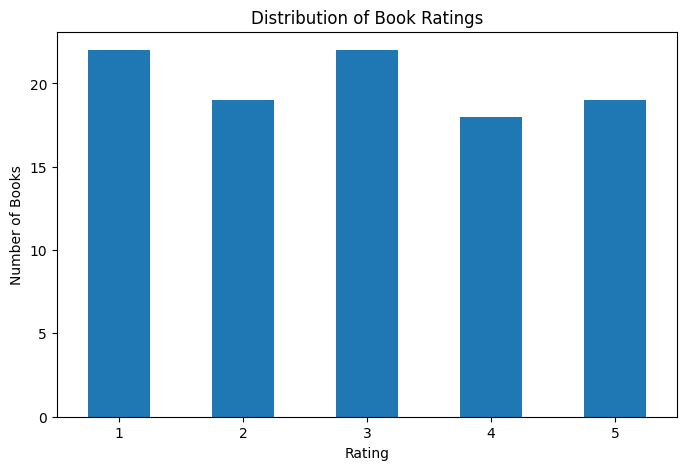

In [37]:
import matplotlib.pyplot as plt

df["Rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)
plt.show()

## Conclusion

In this task, web scraping was performed using Python, Requests, BeautifulSoup, and Pandas.
Data was collected from a publicly available web page and stored in a structured dataset.

The scraper extracted important attributes such as book title, price, availability, and rating.
Multiple web pages were navigated programmatically to collect a larger dataset.

The collected data was cleaned by removing currency symbols, converting prices into numerical
values, and converting ratings into numerical scores.

The final dataset was exported as a CSV file and basic statistical analysis and visualization
were performed.

This task demonstrated the practical use of web scraping, HTML parsing, data cleaning,
dataset creation, and exploratory data analysis.